In [1]:
# 사과 가격 100원 / 사과 개수 2개 / 소비세 1.1
human_z = (100 * 2) * 1.1  # 인간의 계산방식

# 순전파 : 앞으로 계산
a = 100 *2 
deep_z = a * 1.1  # 딥러닝의 계산방식

print(human_z, deep_z)

# 최종금액이 1원 변할 때 사과가격은 얼마나 변할까?

220.00000000000003 220.00000000000003


In [ ]:
# 출력까지 여러 연산으로 이루어짐
# 각 구간의 로컬변화율(미분)을 곱해서
# 최종적으로 DL / DW 구함

# 체인룰 : 출력오차가 앞단 가중치까지 어떻게 전파되는지 계산하는 규칙
# 이 값으로 w - lr*gradient 업데이트 수행

# 신경망 (은닉층 1, 출력층 1)  ->  체이닝 룰
# 입력 x 
# 은닉층 z1 = w1*x + b1, h = relu(z1)
# 출력층 z2 = w2, y_hat = sigmoid(z2)
# 손실 l = 1/2(y - y_hat)**2

In [ ]:
import torch
import matplotlib.pyplot as plt

# 기울기
# f(x) = x^2 f'(x) = 2x

h_value = [1.0, 0.5, 0.1, 0.01, 0.001]

x0 = 3.0
f_prime = 2*x0

for h in h_value:
    gradient = ((x0 + h)**2 - x0**2) / h
    print(f'두 점의 기울기 {gradient}')

print(f'이론상 접선 기울기 {2*x0}') 

두 점의 기울기 7.0
두 점의 기울기 6.5
두 점의 기울기 6.100000000000012
두 점의 기울기 6.009999999999849
두 점의 기울기 6.000999999999479
이론상 접선 기울기 6.0


In [5]:
# 과일 예제 체인룰 코드 증명
# z = (사과가격 * 개수) * 세율

# dz / d사과가격 = 개수 * 세율

import torch
apple_price = torch.tensor(100.0, requires_grad=True)
apple_count = 2.0
tax = 1.1

subtotal = apple_price * apple_count
total_price = subtotal * tax

total_price.backward()

manual_gradient = apple_count * tax
auto_gradient = apple_price.grad.item()

print(manual_gradient, auto_gradient)

2.2 2.200000047683716


In [ ]:
# f(x) = x^2  ->  손실함수
x_manual = 4.0  # 시작점
lr = 0.1
manual_history = [x_manual]

for step in range(20):
    gradient = 2 * x_manual
    x_manual = x_manual - lr * gradient
    manual_history.append(x_manual)
    if step < 8 or step >= 18:
        print(f'step{step+1}: x={x_manual:.4f} gradient={gradient:.4f} f(x)={x_manual**2:.4f}')
    elif step == 8:
        print('----중간생략----')
print(f'최종도달위치: x={x_manual:.6f} (목표 0.0)')

step1: x=3.2000 gradient=8.0000 f(x)=10.2400
step2: x=2.5600 gradient=6.4000 f(x)=6.5536
step3: x=2.0480 gradient=5.1200 f(x)=4.1943
step4: x=1.6384 gradient=4.0960 f(x)=2.6844
step5: x=1.3107 gradient=3.2768 f(x)=1.7180
step6: x=1.0486 gradient=2.6214 f(x)=1.0995
step7: x=0.8389 gradient=2.0972 f(x)=0.7037
step8: x=0.6711 gradient=1.6777 f(x)=0.4504
----중간생략----
step19: x=0.0576 gradient=0.1441 f(x)=0.0033
step20: x=0.0461 gradient=0.1153 f(x)=0.0021
최종도달위치: x=0.046117 (목표 0.0)


In [12]:
import torch

x_pt = torch.tensor([4.0], requires_grad=True)
optimizer = torch.optim.SGD([x_pt], lr=0.1)
pt_history = [x_pt.item()]

for step in range(20):
    optimizer.zero_grad()
    loss = x_pt**2
    loss.backward()  # 자동 미분 / 각 계산 구간별 기울기를 자동으로 구함
    optimizer.step() # 업데이트
    pt_history.append(x_pt.item())
    if step < 3:
        print(f'step{step+1}: x={x_pt.item():.4f} gradient={x_pt.grad.item():.4f} f(x)={x_pt.item()**2:.4f}')

step1: x=3.2000 gradient=8.0000 f(x)=10.2400
step2: x=2.5600 gradient=6.4000 f(x)=6.5536
step3: x=2.0480 gradient=5.1200 f(x)=4.1943


In [19]:
pt_history

[4.0,
 3.200000047683716,
 2.559999942779541,
 2.047999858856201,
 1.6383998394012451,
 1.3107198476791382,
 1.0485758781433105,
 0.8388606905937195,
 0.6710885763168335,
 0.5368708372116089,
 0.4294966757297516,
 0.3435973525047302,
 0.2748778760433197,
 0.21990230679512024,
 0.17592184245586395,
 0.14073747396469116,
 0.11258997768163681,
 0.09007198363542557,
 0.07205758988857269,
 0.057646073400974274,
 0.04611685872077942]

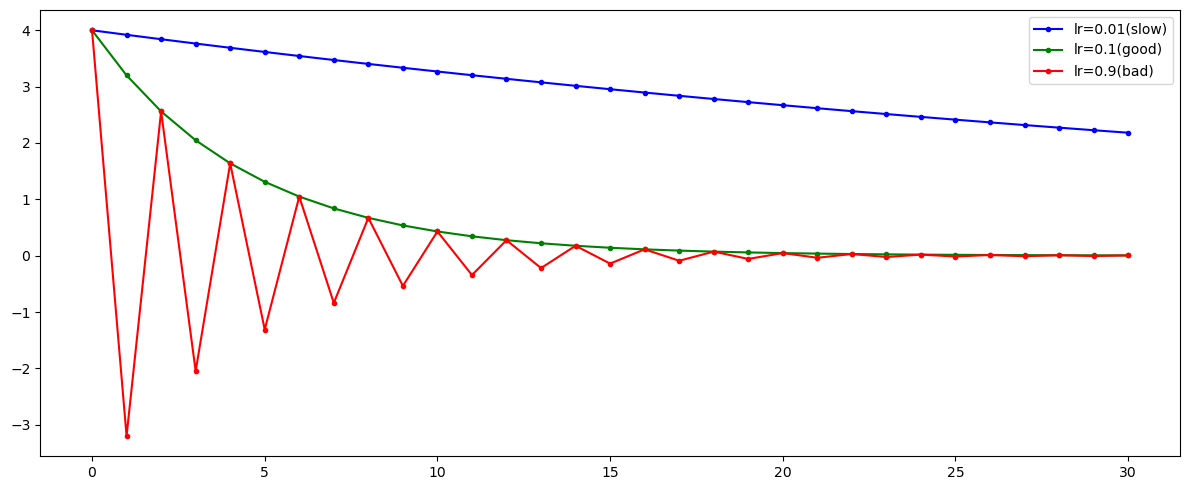

In [ ]:
# 학습률 시각화
import matplotlib.pyplot as plt

lr = [0.01, 0.1, 0.9]
colors = ['blue', 'green', 'red']
labels = ['lr=0.01(slow)', 'lr=0.1(good)', 'lr=0.9(bad)']

fig, ax = plt.subplots(figsize=(12,5))
for lr_val, color, label in zip(lr, colors, labels):
    x_test = 4.0
    history = [x_test]
    for i in range(30):
        grad = 2*x_test
        x_test = x_test - lr_val*grad
        history.append(x_test)
    ax.plot(history, marker='o', markersize=3, color=color, label=label)
plt.legend()
plt.tight_layout()
plt.show()      

In [9]:
# 은닉층 1개 + 출략층 1개 : 체인룰 -> backward
# z1 = w1x + b1, h = activation(z1)
# z2 = w2x + b2, h^ = activation(z2)
# L(loss) = 1/2(y - y^)**2
import torch

def sigmoid_(v):
    return 1/(1+torch.exp(-v))

In [12]:
# 샘플1개 초기파라메터 
x = 1.5
y = 1.0
w1, b1 = 0.5,-0.4
w2, b2 = -1.2, 0.3
lr = 0.1

# 순전파(수동)
z1 = w1*x+b1
h = 1/(1+torch.exp(torch.tensor(-z1))).item()
z2 = w2*h+b2
y_hat = 1/(1+torch.exp(torch.tensor(-z2))).item()
loss = 0.5*(y-y_hat)**2

# 체인룰 미분(수동)
dL_dyhat = (y_hat - y)
dyhat_dz2 =  y_hat*(1-y_hat)
dL_dz2 = dL_dyhat* dyhat_dz2

dL_dw2_manual = dL_dz2*h
dL_db2_manual = dL_dz2

dL_dh = dL_dz2*w2
dh_dz1 = h*(1-h)
dL_dz1 = dL_dh * dh_dz1

dL_dw1_manual = dL_dz1*x
dL_db1_manual = dL_dz1

print(f'dL/dw1 = {dL_dw1_manual} dL/db1 = {dL_db1_manual}')
print(f'dL/dw2 = {dL_dw2_manual} dL/db2 = {dL_db2_manual}')

dL/dw1 = 0.06283611634286862 dL/db1 = 0.04189074422857908
dL/dw2 = -0.08444711785602116 dL/db2 = -0.14395599454121452


In [14]:
# autograde
x_t = torch.tensor([x], dtype=torch.float32)
y_t = torch.tensor([y], dtype=torch.float32)
w1_t = torch.tensor([w1], dtype=torch.float32, requires_grad=True)
b1_t = torch.tensor([b1], dtype=torch.float32, requires_grad=True)
w2_t = torch.tensor([w2], dtype=torch.float32, requires_grad=True)
b2_t = torch.tensor([b2], dtype=torch.float32, requires_grad=True)

h_t = sigmoid_(w1_t*x + b1_t)
y_hat_t = sigmoid_(w2_t*h_t + b2_t)
loss_t = 0.5*(y_hat_t - y_t)**2
loss_t.backward()

print(f'dL/dw1 = {w1_t.grad.item()} dL/db1 = {b1_t.grad.item()}')
print(f'dL/dw2 = {w2_t.grad.item()} dL/db2 = {b2_t.grad.item()}')

abs(dL_dw1_manual - w1_t.grad.item()), abs(dL_db1_manual - b1_t.grad.item())

dL/dw1 = 0.06283612549304962 dL/db1 = 0.04189075157046318
dL/dw2 = -0.08444712311029434 dL/db2 = -0.1439560055732727


(9.150181001782443e-09, 7.3418841006756e-09)

In [15]:
# 경사하강법
with torch.no_grad():
    w1_new = w1_t - lr*w1_t.grad
    b1_new = b1_t - lr*b1_t.grad
    w2_new = w2_t - lr*w2_t.grad
    b2_new = b2_t - lr*b2_t.grad

h_new = sigmoid_(w1_new*x_t + b1_new)
y_hat_new = sigmoid_(w2_new*h_new + b2_new)
loss_new = 0.5*(y_hat_new - y_t)**2

print(f'업데이트 전 loss {loss_t.item()}')
print(f'업데이트 후 loss {loss_new.item()}')

업데이트 전 loss 0.17978057265281677
업데이트 후 loss 0.176436185836792


In [54]:
import seaborn as sns
import torch

data = sns.load_dataset('titanic')
data = data.dropna()
X = data.loc[:, 'pclass':]
y = data['survived'].to_numpy()

X.drop(['class', 'sex', 'alive', 'embarked', 'embark_town'], axis=1)

X

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [55]:
# 수치형 standard / 범주형 onehot
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

numeric_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical_cols = ['embarked', 'who', 'adult_male', 'alone']
numeric_pipe = Pipeline([
    ('scaler', StandardScaler())
])
categorical_pipe = Pipeline([
    ('onehot', OneHotEncoder())
])

transformer = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, numeric_cols),
        ('cat', categorical_pipe, categorical_cols)
    ]
)

x_train_full, x_test, y_train_full, y_test = train_test_split(X, y ,stratify=y, random_state=42)
x_train, x_valid, y_train, y_valid = train_test_split(x_train_full, y_train_full, stratify=y_train_full, random_state=42)

x_train.shape, x_valid.shape, x_test.shape

((102, 14), (34, 14), (46, 14))

In [56]:
x_train = transformer.fit_transform(x_train)
x_valid = transformer.transform(x_valid)
x_test = transformer.transform(x_test)

x_train.shape, x_valid.shape, x_test.shape

((102, 15), (34, 15), (46, 15))

In [57]:
import torch.nn as nn
class TitanicDNN(nn.Module):
    def __init__(self, input_dim=15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.net(x)

model = TitanicDNN()

In [58]:
x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_val_t = torch.tensor(x_valid, dtype=torch.float32)
x_test_t = torch.tensor(x_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t = torch.tensor(y_valid, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

In [67]:
# 손실함수
bce = nn.BCELoss()
loss = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
epochs = 100
train_losses, val_losses = [],[]
for epoch in range(epochs):
    optimizer.zero_grad()
    # forward
    predict = model(x_train_t)
    loss = bce(predict, y_train_t.unsqueeze(1))
    # backward
    loss.backward()
    # update
    optimizer.step()

# val로 가중치 추론
with torch.no_grad():
    val_output = model(x_val_t)
    val_loss = bce(val_output, y_val_t.unsqueeze(1))

print(f'epoch : {epoch+1} loss:{loss.item():.4f} val_loss : {val_loss.item():.4f}')
train_losses.append(loss.item())
val_losses.append(val_loss.item())

# import matplotlib.pyplot as plt
# plt.plot(range(1,epochs+1), train_losses, label = 'train loss')
# plt.plot(range(1,epochs+1), val_losses, label = 'val loss')
# plt.legend()
# plt.show()

sum( (model(x_test_t)>=0.5).float().squeeze(1) == y_test ) / len(y_test)

epoch : 100 loss:0.0897 val_loss : 0.9410


TypeError: 'bool' object is not iterable

In [ ]:
%pip install flaml[automl]

In [68]:
from flaml import AutoML
automl = AutoML()
automl_settings = {
    "time_budget": 1,  # in seconds
    "metric": "accuracy",
    "task": "classification",
    "log_file_name": "iris.log",
}
automl.fit(X_train=x_train, y_train=y_train, **automl_settings)

sum(automl.predict(x_test) == y_test) / len(y_test), automl.best_config , automl.best_estimator

[flaml.automl.logger: 04-22 17:18:39] {2375} INFO - task = classification
[flaml.automl.logger: 04-22 17:18:39] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 04-22 17:18:39] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 04-22 17:18:39] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 04-22 17:18:39] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 04-22 17:18:39] {3046} INFO - Estimated sufficient time budget=430s. Estimated necessary time budget=10s.
[flaml.automl.logger: 04-22 17:18:39] {3097} INFO -  at 0.1s,	estimator lgbm's best error=3.2333e-01,	best estimator lgbm's best error=3.2333e-01
[flaml.automl.logger: 04-22 17:18:39] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 04-22 17:18:39] {3097} INFO -  at 0.1s,	estimator lgbm's best error=3.2333e-01,	best estimator lgbm's best error=3.2333e-01
[flaml.autom

c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: U

[flaml.automl.logger: 04-22 17:18:39] {3097} INFO -  at 0.2s,	estimator sgd's best error=2.5476e-01,	best estimator sgd's best error=2.5476e-01
[flaml.automl.logger: 04-22 17:18:39] {2911} INFO - iteration 4, current learner xgboost
[flaml.automl.logger: 04-22 17:18:39] {3097} INFO -  at 0.2s,	estimator xgboost's best error=3.2333e-01,	best estimator sgd's best error=2.5476e-01
[flaml.automl.logger: 04-22 17:18:39] {2911} INFO - iteration 5, current learner lgbm
[flaml.automl.logger: 04-22 17:18:39] {3097} INFO -  at 0.3s,	estimator lgbm's best error=2.7476e-01,	best estimator sgd's best error=2.5476e-01
[flaml.automl.logger: 04-22 17:18:39] {2911} INFO - iteration 6, current learner xgboost
[flaml.automl.logger: 04-22 17:18:39] {3097} INFO -  at 0.3s,	estimator xgboost's best error=3.2333e-01,	best estimator sgd's best error=2.5476e-01
[flaml.automl.logger: 04-22 17:18:39] {2911} INFO - iteration 7, current learner lgbm
[flaml.automl.logger: 04-22 17:18:39] {3097} INFO -  at 0.4s,	est

c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: U

[flaml.automl.logger: 04-22 17:18:39] {2911} INFO - iteration 10, current learner xgboost
[flaml.automl.logger: 04-22 17:18:39] {3097} INFO -  at 0.5s,	estimator xgboost's best error=2.5524e-01,	best estimator sgd's best error=2.5476e-01
[flaml.automl.logger: 04-22 17:18:39] {2911} INFO - iteration 11, current learner xgboost
[flaml.automl.logger: 04-22 17:18:39] {3097} INFO -  at 0.5s,	estimator xgboost's best error=2.5524e-01,	best estimator sgd's best error=2.5476e-01
[flaml.automl.logger: 04-22 17:18:39] {2911} INFO - iteration 12, current learner xgboost
[flaml.automl.logger: 04-22 17:18:39] {3097} INFO -  at 0.6s,	estimator xgboost's best error=2.5524e-01,	best estimator sgd's best error=2.5476e-01
[flaml.automl.logger: 04-22 17:18:39] {2911} INFO - iteration 13, current learner xgboost
[flaml.automl.logger: 04-22 17:18:39] {3097} INFO -  at 0.6s,	estimator xgboost's best error=2.4524e-01,	best estimator xgboost's best error=2.4524e-01
[flaml.automl.logger: 04-22 17:18:39] {2911}

c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: U

[flaml.automl.logger: 04-22 17:18:40] {3097} INFO -  at 1.0s,	estimator extra_tree's best error=2.3429e-01,	best estimator sgd's best error=2.0524e-01
[flaml.automl.logger: 04-22 17:18:40] {3359} INFO - retrain sgd for 0.0s
[flaml.automl.logger: 04-22 17:18:40] {3362} INFO - retrained model: SGDClassifier(alpha=0.00048220009927335403, eta0=0.0073280898930720125,
              learning_rate='constant', loss='modified_huber', n_jobs=-1,
              penalty=None, tol=0.0001)
[flaml.automl.logger: 04-22 17:18:40] {2636} INFO - fit succeeded
[flaml.automl.logger: 04-22 17:18:40] {2637} INFO - Time taken to find the best model: 0.7947409152984619


(0.8043478260869565,
 {'penalty': 'None',
  'alpha': 0.00048220009927335403,
  'l1_ratio': 0.00870574889667242,
  'epsilon': 0.1,
  'learning_rate': 'constant',
  'eta0': 0.0073280898930720125,
  'power_t': 0.47436097801285154,
  'average': False,
  'loss': 'modified_huber'},
 'sgd')